# Intelligent Agents: Reflex-Based Agents for the Vacuum-cleaner World

Student Name: Zahra Hoobakht

I have used the following AI tools: [list tools]

I understand that my submission needs to be my own work: ZH

## Instructions

Total Points: Undergrads 100 + 5 bonus / Graduate students 110

Complete this notebook. Use the provided notebook cells and insert additional code and markdown cells as needed. Submit the completely rendered notebook as a HTML file.

In Visual Studio Code: Use Export (click on ... in the menu bar) to save your notebook as a HTML file.

In Colab you need to save the notebook on GoogleDrive and then add the following block

In [1]:
# !pip install nbconvert
#
# from google.colab import drive
# drive.mount('/content/drive')
# !jupyter nbconvert --to html /content/drive/MyDrive/Colab\ Notebooks/Copy\ of\ robot_vacuum.ipynb

You will need to fix the file location on your GoogleDrive.

## Introduction

In this assignment you will implement a simulator environment for an automatic vacuum cleaner robot, a set of different reflex-based agent programs, and perform a comparison study for cleaning a single room. Focus on the __cleaning phase__ which starts when the robot is activated and ends when the last dirty square in the room has been cleaned. Someone else will take care of the agent program needed to navigate back to the charging station after the room is clean.

## PEAS description of the cleaning phase

__Performance Measure:__ Each action costs 1 energy unit. The performance is measured as the sum of the energy units used to clean the whole room.

__Environment:__ A room with $n \times n$ squares where $n = 5$. Dirt is randomly placed on each square with probability $p = 0.2$. For simplicity, you can assume that the agent knows the size and the layout of the room (i.e., it knows $n$). To start, the agent is placed on a random square.

__Actuators:__ The agent can clean the current square (action `suck`) or move to an adjacent square by going `north`, `east`, `south`, or `west`.

__Sensors:__ Four bumper sensors, one for north, east, south, and west; a dirt sensor reporting dirt in the current square.  


## The agent program for a simple randomized agent

The agent program is a function that gets sensor information (the current percepts) as the arguments. The arguments are:

* A dictionary with boolean entries for the for bumper sensors `north`, `east`, `west`, `south`. E.g., if the agent is on the north-west corner, `bumpers` will be `{"north" : True, "east" : False, "south" : False, "west" : True}`.
* The dirt sensor produces a boolean.

The agent returns the chosen action as a string.

Here is an example implementation for the agent program of a simple randomized agent:  

In [2]:
# make sure numpy is installed
#!pip install -q numpy

In [3]:
import numpy as np

actions = ["north", "east", "west", "south", "suck"]
 
def simple_randomized_agent(bumpers, dirty):
    return np.random.choice(actions)

In [4]:
# define percepts (current location is NW corner and it is dirty)
bumpers = {"north" : True, "east" : False, "south" : False, "west" : True}
dirty = True

# call agent program function with percepts and it returns an action
simple_randomized_agent(bumpers, dirty)

'south'

__Note:__ This is not a rational intelligent agent. It ignores its sensors and may bump into a wall repeatedly or not clean a dirty square. You will be asked to implement rational agents below.

## Simple environment example

We implement a simple simulation environment that supplies the agent with its percepts.
The simple environment is infinite in size (bumpers are always `False`) and every square is always dirty, even if the agent cleans it. The environment function returns a different performance measure than the one specified in the PEAS description! Since the room is infinite and all squares are constantly dirty, the agent can never clean the whole room. Your implementation needs to implement the **correct performance measure.** The energy budget of the agent is specified as `max_steps`.

In [5]:
def simple_environment(agent, max_steps, verbose = True):
    num_cleaned = 0

    for i in range(max_steps):
        dirty = True
        bumpers = {"north" : False, "south" : False, "west" : False, "east" : False}

        action = agent(bumpers, dirty)
        if (verbose): print("step", i , "- action:", action)

        if (action == "suck"):
            num_cleaned = num_cleaned + 1

    return num_cleaned



Do one simulation run with a simple randomized agent that has enough energy for 20 steps.

In [6]:
simple_environment(simple_randomized_agent, max_steps = 20)

step 0 - action: west
step 1 - action: south
step 2 - action: suck
step 3 - action: south
step 4 - action: suck
step 5 - action: suck
step 6 - action: north
step 7 - action: south
step 8 - action: suck
step 9 - action: south
step 10 - action: north
step 11 - action: north
step 12 - action: south
step 13 - action: west
step 14 - action: south
step 15 - action: east
step 16 - action: south
step 17 - action: south
step 18 - action: west
step 19 - action: suck


5

# Tasks

## General [10 Points]

1. Make sure that you use the latest version of this notebook.
2. Your implementation can use libraries like math, numpy, scipy, but not libraries that implement intelligent agents or complete search algorithms. Try to keep the code simple! In this course, we want to learn about the algorithms and we often do not need to use object-oriented design.
3. You notebook needs to be formatted professionally.
    - Add additional markdown blocks for your description, comments in the code, add tables and use mathplotlib to produce charts where appropriate
    - Do not show debugging output or include an excessive amount of output.
    - Check that your submitted file is readable. For example, long lines may get cut off. You don't have control over page breaks, so do not worry about these.
4. Document your code. Add a short discussion of how your implementation works and your design choices.


## Task 1: Implement a simulation environment [20 Points]

The simple environment above is not very realistic. Your environment simulator needs to follow the PEAS description from above. It needs to:

* Initialize the environment by storing the state of each square (clean/dirty) and making some dirty. ([Help with random numbers and arrays in Python](https://github.com/mhahsler/CS7320-AI/blob/master/HOWTOs/random_numbers_and_arrays.ipynb))
* Keep track of the agent's position.
* Call the agent function repeatedly and provide the agent function with the sensor inputs.  
* React to the agent's actions. E.g, by removing dirt from a square or moving the agent around unless there is a wall in the way.
* Keep track of the performance measure. That is, track the agent's actions until all dirty squares are clean and count the number of actions it takes the agent to complete the task.

The easiest implementation for the environment is to hold an 2-dimensional array to represent if squares are clean or dirty and to call the agent function in a loop until all squares are clean or a predefined number of steps have been reached (i.e., the robot runs out of energy).

The simulation environment should be a function like the `simple_environment()` and needs to work with the simple randomized agent program from above. **Use the same environment for all your agent implementations in the tasks below.**

*Note on debugging:* Debugging is difficult. Make sure your environment prints enough information when you use `verbose = True`. Also, implementing a function that the environment can use to displays the room with dirt and the current position of the robot at every step is very useful.  

In [7]:
def initial_position_def(n,p):
    #Initialize the environment by storing the state of each square (clean/dirty) and making some dirty
    rng = np.random.default_rng()
    env_agent=rng.choice([1, 0], size = (n,n),  p=[p[0], p[1]])
    initial_position_agent= np.random.randint(0, 5, size=2) #initial position for agent
    return env_agent,initial_position_agent
n=5
p = [0.2, 0.8]
[env_agent,initial_position_agent]=initial_position_def(n,p)

In [8]:
env_agent

array([[1, 0, 0, 0, 1],
       [1, 0, 0, 1, 1],
       [1, 1, 0, 0, 0],
       [0, 0, 0, 0, 1],
       [0, 0, 0, 1, 1]])

In [9]:
initial_position_agent

array([1, 0])

In [10]:
max_steps1=100
def simple_environment1(agent, max_steps,env_agent,initial_position_agent,N, verbose = True):
    initial_position=initial_position_agent.copy()
    env=env_agent.copy()
    num_cleaned = 0
    Performance_measure=0
    for i in range(max_steps):
        print("agent's location is",[initial_position[0],initial_position[1]])
        if env[initial_position[0],initial_position[1]]==1:
            print("agent's location is dirty")
        elif env[initial_position[0],initial_position[1]]==0:
            print("agent's location is clean")
        action = agent(initial_position, env[initial_position[0],initial_position[1]])
        
        
        a=True
           
        #print(initial_position[0],initial_position[1],env[initial_position[0],initial_position[1]])
        if (verbose): print("step", i , "- action:", action)
        if action=='north' and initial_position[0]>0:
            initial_position[0]-=1         
            Performance_measure+=1
        elif action=='south' and initial_position[0]<N-1:
            initial_position[0]+=1
            Performance_measure+=1
        elif action=='east'and initial_position[1]<N-1:
            initial_position[1]+=1
            Performance_measure+=1
        elif action=='west' and initial_position[1]>0:
            initial_position[1]-=1 
            Performance_measure+=1
           
        

        elif (action == "suck") and (env[initial_position[0],initial_position[1]]==1):
            num_cleaned = num_cleaned + 1
            Performance_measure+=1
            env[initial_position[0],initial_position[1]]=0
            print('agent cleaned the spot')
        elif (action == "suck") and (env[initial_position[0],initial_position[1]]==0):
            num_cleaned = num_cleaned
            Performance_measure+=1
            print('The spot was clean-wrong action')
        else:
            print('wall, agent remains to the position')
            Performance_measure+=1
        
        print('number of dirty squares are',np.sum(env))
        print('performance measure is',Performance_measure)
        print('-'*30)
    return print('agent sucessfully cleaned',num_cleaned,"number of squares, the environment matrix is:",'\n ',env)
N=5
simple_environment1(simple_randomized_agent, max_steps1 ,env_agent,initial_position_agent,N)

agent's location is [1, 0]
agent's location is dirty
step 0 - action: west
wall, agent remains to the position
number of dirty squares are 10
performance measure is 1
------------------------------
agent's location is [1, 0]
agent's location is dirty
step 1 - action: west
wall, agent remains to the position
number of dirty squares are 10
performance measure is 2
------------------------------
agent's location is [1, 0]
agent's location is dirty
step 2 - action: suck
agent cleaned the spot
number of dirty squares are 9
performance measure is 3
------------------------------
agent's location is [1, 0]
agent's location is clean
step 3 - action: south
number of dirty squares are 9
performance measure is 4
------------------------------
agent's location is [2, 0]
agent's location is dirty
step 4 - action: suck
agent cleaned the spot
number of dirty squares are 8
performance measure is 5
------------------------------
agent's location is [2, 0]
agent's location is clean
step 5 - action: west

## Task 2:  Implement a simple reflex agent [10 Points]

The simple reflex agent randomly walks around but reacts to the bumper sensor by not bumping into the wall and to dirt with sucking. Implement the agent program as a function.

_Note:_ Agents cannot directly use variable in the environment. They only gets the percepts as the arguments to the agent function. Use the function signature for the `simple_randomized_agent` function above.

In [11]:
class Agent:
    def __init__(self, initial_position):
        self.initial_position=initial_position
        
    def act(self, percept_action,agent_position,N): 
        if percept_action==1:
            return('suck')
        else:
            if agent_position[0]==0 and 0<agent_position[1]<N-1:
                return(np.random.choice(["east", "west", "south"]))
            elif agent_position[0]==0 and agent_position[1]==0:
                return(np.random.choice(["east", "south"]))
            elif agent_position[0]==0 and agent_position[1]==N-1:
                return(np.random.choice(["west", "south"]))
            elif agent_position[0]==N-1 and 0<agent_position[1]<N-1:
                return(np.random.choice(["north", "east", "west"]))
            elif agent_position[0]==N-1 and agent_position[1]==0:
                return(np.random.choice(["north", "east"]))
            elif agent_position[0]==N-1 and agent_position[1]==N-1:
                return(np.random.choice(["north", "west"]))
            
            elif 0<agent_position[0]<N-1 and agent_position[1]==0:
                return(np.random.choice(["north", "east",  "south"]))
            elif 0<agent_position[0]<N-1 and agent_position[1]==N-1:
                return(np.random.choice(["north", "west", "south"]))
            else:
                return(np.random.choice(["north", "east", "west", "south"]))
def agent_environment(agent_act,initial_position_agent,env_agent, max_step,N): 
    Performance_measure=0
    num_cleaned=0
    agent_position=initial_position_agent.copy()
    env=env_agent.copy()
    for i in range(max_step):
        action_valid = False
        print("Step", i)
        if env[agent_position[0],agent_position[1]]==0:
            print("  Environment: Agent's action is in position", agent_position, "and the position is clean")
            
        elif env[agent_position[0],agent_position[1]]==1:
            print("  Environment: Agent's action is in position", agent_position, "and the position is dirty")
        action=agent_act(env[agent_position[0],agent_position[1]],[agent_position[0],agent_position[1]],N)
        if action=='suck':
            print('Action chosen:',action)
            num_cleaned += 1
            Performance_measure+=1
            env[agent_position[0], agent_position[1]] = 0
            print('agent cleaned the spot')
        else:
           
            
            if action == 'north':
                agent_position[0] -= 1
                Performance_measure+=1
                action_valid = True
            elif action == 'south' :
                agent_position[0] += 1
                Performance_measure+=1
                action_valid = True
            elif action == 'east' :
                agent_position[1] += 1
                Performance_measure+=1
                action_valid = True
            elif action == 'west' :
                agent_position[1] -= 1
                Performance_measure+=1
                action_valid = True

            print('Action chosen:',action)
        
        print('number of dirty squares are', np.sum(env))
        
        print('performance measure is', Performance_measure)

        print('-' * 30)

    return print('agent successfully cleaned', num_cleaned, "number of squares, the environment matrix is:", '\n', env)
N=5    
agent1 = Agent(initial_position_agent)
agent_environment(agent1.act,initial_position_agent,env_agent, max_steps1,N)

Step 0
  Environment: Agent's action is in position [1 0] and the position is dirty
Action chosen: suck
agent cleaned the spot
number of dirty squares are 9
performance measure is 1
------------------------------
Step 1
  Environment: Agent's action is in position [1 0] and the position is clean
Action chosen: north
number of dirty squares are 9
performance measure is 2
------------------------------
Step 2
  Environment: Agent's action is in position [0 0] and the position is dirty
Action chosen: suck
agent cleaned the spot
number of dirty squares are 8
performance measure is 3
------------------------------
Step 3
  Environment: Agent's action is in position [0 0] and the position is clean
Action chosen: east
number of dirty squares are 8
performance measure is 4
------------------------------
Step 4
  Environment: Agent's action is in position [0 1] and the position is clean
Action chosen: west
number of dirty squares are 8
performance measure is 5
------------------------------
Ste

## Task 3: Implement a model-based reflex agent [20 Points]

Model-based agents use a state to keep track of what they have done and perceived so far. Your agent needs to find out where it is located and then keep track of its current location. You also need a set of rules based on the state and the percepts to make sure that the agent will clean the whole room. For example, the agent can move to a corner to determine its location and then it can navigate through the whole room and clean dirty squares.

Describe how you define the __agent state__ and how your agent works before implementing it. ([Help with implementing state information on Python](https://github.com/mhahsler/CS7320-AI/blob/master/HOWTOs/store_agent_state_information.ipynb))

In this section, I defined an update_position function to give the agent memory of its visited positions. The agent starts from a random point and get action to rach to [0,0] point. Then from [0,0] point it starts cleaning and perceives whether the current grid cell is clean (0) or dirty (1) and paving cells in a vertical columns, avoiding revisited cells. If the agent recognize wall in the south, change the path, one cell to the east, checking that the agent stays within bounds and check the memory to make sure it hasn't visited that cell. If the move is valid, the environment updates the agent's position, and the agent continues making decision. If the agent encounters a dirty cell, it performs a "suck" action to clean it. 
The program tracks how many cells the agent cleans and evaluates its performance. 

In [12]:
max_steps1=100
class Agent:
    def __init__(self, initial_position):
        #self.initial_position=initial_position
        self.position_history = [[initial_position.copy()[0],initial_position.copy()[1]]]
        
    def update_position(self, new_position=None):
        if (new_position is not None) :
            new_position_tuple = tuple(new_position)
            # Convert position_history elements to tuples for comparison
            if new_position_tuple not in [tuple(pos) for pos in self.position_history]:
                self.position_history.append(new_position.copy())

        return(self.position_history)
                                     
    def act(self, new_position, percept_action=None,reset=None,N=5): 
        if reset==1:
            if new_position[0]>0:
                
                while new_position[0]>0:
                    new_position[0]-=1
                    
                    return('north')
            elif new_position[0]==0 and new_position[1]>0:
                while new_position[1]>0:
                    new_position[1]-=1
                    
                    return('west')
            else: 
                pass
                
        
        elif percept_action==1:
            return('suck')
        else:
            if new_position[1]%2==0 and new_position[0]!=N-1:
                return('south')
            
            elif new_position[1]%2==1 and new_position[0]!=0:
                return('north')
            else:
                return('east')
            
        
        
        
def agent_environment(agent_act,agent_update_position,initial_position_agent,env_agent, max_step,N=5): 

    num_cleaned=0
    agent_position=initial_position_agent.copy()
    env=env_agent.copy()
    performance_measure=0

    start=True
    for i in range(max_step):
       
        print("Step", i)
        if start:
            
            action=agent_act([agent_position[0],agent_position[1]],reset=1,N=5)
            print(action)
            
            if agent_position[0]>0 and action=='north':
                agent_position[0]-=1
                performance_measure+=1
                print('performance measure is', performance_measure)
                if agent_position[0]==0 and agent_position[1]==0:
                    agent_update_position().clear()
                    start=False
            elif agent_position[1]>0 and action=='west':
                agent_position[1]-=1
                performance_measure+=1
                print('performance measure is', performance_measure)
                if agent_position[0]==0 and agent_position[1]==0:
                    agent_update_position().clear()
                    start=False
           
            agent_update_position([agent_position[0],agent_position[1]])
            print('-' * 30)
        else:
            if env[agent_position[0],agent_position[1]]==0:
                print("  Environment: Agent's action is in position", agent_position, "and the position is clean")

            elif env[agent_position[0],agent_position[1]]==1:
                print("  Environment: Agent's action is in position", agent_position, "and the position is dirty")

            action=agent_act([agent_position[0],agent_position[1]],env[agent_position[0],agent_position[1]],N=5)



            print(action)
            if action=='suck':
                print('Action chosen:',action)
                num_cleaned += 1
                performance_measure+=1
                env[agent_position[0], agent_position[1]] = 0
                print('agent cleaned the spot')
            else:

                if (action == 'north' and agent_position[0] > 0) and ([agent_position[0]-1,agent_position[1]] not in agent_update_position()):  

                    agent_position[0] -= 1
                    performance_measure+=1

                elif (action == 'south' and agent_position[0] < N-1) and ([agent_position[0]+1,agent_position[1]] not in agent_update_position()):  
                    agent_position[0] += 1                                 
                    performance_measure+=1

                elif (action == 'east' and agent_position[1] < N-1) and ([agent_position[0],agent_position[1]+1] not in agent_update_position()):  

                    agent_position[1] += 1                                     
                    performance_measure+=1

                elif (action == 'west' and agent_position[1] > 0) and ([agent_position[0],agent_position[1]-1] not in agent_update_position()):  

                    agent_position[1] -= 1                     
                    performance_measure+=1

                print('Action chosen:',action)
                print('The agent history so far is:',agent_update_position())
                print('agent sweeps', len(agent_update_position()))
                agent_update_position([agent_position[0],agent_position[1]])

            print('number of dirty squares are', np.sum(env))
            print('performance measure is', performance_measure)
            print('-' * 30)
            if np.sum(env)==0 and len(agent_update_position())==N*N:
                break
        print('The agent history so far is:',agent_update_position())
        print('agent sweeps', len(agent_update_position()))    
    return print('agent successfully cleaned', num_cleaned, "number of squares, the environment matrix is:", '\n', env,'\n performance measure is:',performance_measure)
N=5
    
agent1 = Agent(initial_position_agent)
agent_environment(agent1.act,agent1.update_position,initial_position_agent,env_agent, max_steps1,N)

Step 0
north
performance measure is 1
------------------------------
The agent history so far is: [[0, 0]]
agent sweeps 1
Step 1
  Environment: Agent's action is in position [0 0] and the position is dirty
suck
Action chosen: suck
agent cleaned the spot
number of dirty squares are 9
performance measure is 2
------------------------------
The agent history so far is: [[0, 0]]
agent sweeps 1
Step 2
  Environment: Agent's action is in position [0 0] and the position is clean
south
Action chosen: south
The agent history so far is: [[0, 0]]
agent sweeps 1
number of dirty squares are 9
performance measure is 3
------------------------------
The agent history so far is: [[0, 0], [1, 0]]
agent sweeps 2
Step 3
  Environment: Agent's action is in position [1 0] and the position is dirty
suck
Action chosen: suck
agent cleaned the spot
number of dirty squares are 8
performance measure is 4
------------------------------
The agent history so far is: [[0, 0], [1, 0]]
agent sweeps 2
Step 4
  Environm

## Task 4: Simulation study [30 Points]

Compare the performance (the performance measure is defined in the PEAS description above) of the agents using  environments of different size. E.g., $5 \times 5$, $10 \times 10$ and
$100 \times 100$. Use 100 random runs for each. Present the results using tables and graphs. Discuss the differences between the agents.
([Help with charts and tables in Python](https://github.com/mhahsler/CS7320-AI/blob/master/HOWTOs/charts_and_tables.ipynb))

In [13]:
def Randomized_Agent(agent, max_steps,env_agent,initial_position_agent,N,verbose=True):

    initial_position=initial_position_agent.copy()
    env=env_agent.copy()
    num_cleaned = 0
    Performance_measure=0
    for i in range(max_steps):
#         print("agent's location is",[initial_position[0],initial_position[1]])
#         if env[initial_position[0],initial_position[1]]==1:
#             print("agent's location is dirty")
#         elif env[initial_position[0],initial_position[1]]==0:
#             print("agent's location is clean")
        action = agent(initial_position, env[initial_position[0],initial_position[1]])


        a=True

        #print(initial_position[0],initial_position[1],env[initial_position[0],initial_position[1]])
        #if (verbose): print("step", i , "- action:", action)
        if action=='north' and initial_position[0]>0:
            initial_position[0]-=1         
            Performance_measure+=1
        elif action=='south' and initial_position[0]<N-1:
            initial_position[0]+=1
            Performance_measure+=1
        elif action=='east'and initial_position[1]<N-1:
            initial_position[1]+=1
            Performance_measure+=1
        elif action=='west' and initial_position[1]>0:
            initial_position[1]-=1 
            Performance_measure+=1



        elif (action == "suck") and (env[initial_position[0],initial_position[1]]==1):
            num_cleaned = num_cleaned + 1
            Performance_measure+=1
            env[initial_position[0],initial_position[1]]=0
#             print('agent cleaned the spot')
        elif (action == "suck") and (env[initial_position[0],initial_position[1]]==0):
            num_cleaned = num_cleaned
            Performance_measure+=1
#             print('The spot was clean-wrong action')
        else:
#             print('wall, agent remains to the position')
            Performance_measure+=1

#         print('number of dirty squares are',np.sum(env))
#         print('performance measure is',Performance_measure)
#         print('-'*30)
    return num_cleaned,env,Performance_measure

[num_cleaned,env,Performance_measure]= Randomized_Agent(simple_randomized_agent, max_steps1 ,env_agent,initial_position_agent,N)

In [14]:
num_cleaned,env,Performance_measure

(4,
 array([[0, 0, 0, 0, 0],
        [1, 0, 0, 0, 1],
        [0, 1, 0, 0, 0],
        [0, 0, 0, 0, 1],
        [0, 0, 0, 1, 1]]),
 100)

In [15]:
def Simple_Reflex_Agent(env_agent, max_steps1,initial_position_agent,N):
    class Agent:
        def __init__(self, initial_position):
            self.initial_position=initial_position

        def act(self, percept_action,agent_position,N): 
            if percept_action==1:
                return('suck')
            else:
                if agent_position[0]==0 and 0<agent_position[1]<N-1:
                    return(np.random.choice(["east", "west", "south"]))
                elif agent_position[0]==0 and agent_position[1]==0:
                    return(np.random.choice(["east", "south"]))
                elif agent_position[0]==0 and agent_position[1]==N-1:
                    return(np.random.choice(["west", "south"]))
                elif agent_position[0]==N-1 and 0<agent_position[1]<N-1:
                    return(np.random.choice(["north", "east", "west"]))
                elif agent_position[0]==N-1 and agent_position[1]==0:
                    return(np.random.choice(["north", "east"]))
                elif agent_position[0]==N-1 and agent_position[1]==N-1:
                    return(np.random.choice(["north", "west"]))

                elif 0<agent_position[0]<N-1 and agent_position[1]==0:
                    return(np.random.choice(["north", "east",  "south"]))
                elif 0<agent_position[0]<N-1 and agent_position[1]==N-1:
                    return(np.random.choice(["north", "west", "south"]))
                else:
                    return(np.random.choice(["north", "east", "west", "south"]))
    def agent_environment(agent_act,initial_position_agent,env_agent, max_step,N): 
        Performance_measure=0
        num_cleaned=0
        agent_position=initial_position_agent.copy()
        env=env_agent.copy()
        for i in range(max_step):
            action_valid = False
#             print("Step", i)
#             if env[agent_position[0],agent_position[1]]==0:
#                 print("  Environment: Agent's action is in position", agent_position, "and the position is clean")

#             elif env[agent_position[0],agent_position[1]]==1:
#                 print("  Environment: Agent's action is in position", agent_position, "and the position is dirty")
            action=agent_act(env[agent_position[0],agent_position[1]],[agent_position[0],agent_position[1]],N)
            if action=='suck':
#                 print('Action chosen:',action)
                num_cleaned += 1
                Performance_measure+=1
                env[agent_position[0], agent_position[1]] = 0
#                 print('agent cleaned the spot')
            else:


                if action == 'north':
                    agent_position[0] -= 1
                    Performance_measure+=1
                    action_valid = True
                elif action == 'south' :
                    agent_position[0] += 1
                    Performance_measure+=1
                    action_valid = True
                elif action == 'east' :
                    agent_position[1] += 1
                    Performance_measure+=1
                    action_valid = True
                elif action == 'west' :
                    agent_position[1] -= 1
                    Performance_measure+=1
                    action_valid = True

#                 print('Action chosen:',action)

#             print('number of dirty squares are', np.sum(env))

#             print('performance measure is', Performance_measure)

#             print('-' * 30)

        return num_cleaned, env,Performance_measure
      
    agent1 = Agent(initial_position_agent)
    [num_cleaned, env,Performance_measure]=agent_environment(agent1.act,initial_position_agent,env_agent, max_steps1,N)
    return  num_cleaned, env,Performance_measure
      
[num_cleaned_S, env_S,Performance_measure_S]= Simple_Reflex_Agent(env_agent, max_steps1,initial_position_agent,N)

In [16]:
num_cleaned_S, env_S,Performance_measure_S

(10,
 array([[0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0]]),
 100)

In [17]:
def Model_based_Reflex_Agent(env_agent, max_steps1,initial_position_agent,N):
    class Agent:
        def __init__(self, initial_position):
            #self.initial_position=initial_position
            self.position_history = [[initial_position.copy()[0],initial_position.copy()[1]]]

        def update_position(self, new_position=None):
            if (new_position is not None) :
                new_position_tuple = tuple(new_position)
                # Convert position_history elements to tuples for comparison
                if new_position_tuple not in [tuple(pos) for pos in self.position_history]:
                    self.position_history.append(new_position.copy())

            return(self.position_history)

        def act(self, new_position, percept_action=None,reset=None,N=5): 
            if reset==1:
                if new_position[0]>0:

                    while new_position[0]>0:
                        new_position[0]-=1

                        return('north')
                elif new_position[0]==0 and new_position[1]>0:
                    while new_position[1]>0:
                        new_position[1]-=1

                        return('west')
                else: 
                    pass


            elif percept_action==1:
                return('suck')
            else:
                if new_position[1]%2==0 and new_position[0]!=N-1:
                    return('south')

                elif new_position[1]%2==1 and new_position[0]!=0:
                    return('north')
                else:
                    return('east')




    def agent_environment(agent_act,agent_update_position,initial_position_agent,env_agent, max_step,N=5): 

        num_cleaned=0
        agent_position=initial_position_agent.copy()
        env=env_agent.copy()
        performance_measure=0

        start=True
        for i in range(max_step):

#             print("Step", i)
            if start:

                action=agent_act([agent_position[0],agent_position[1]],reset=1,N=5)
#                 print(action)

                if agent_position[0]>0 and action=='north':
                    agent_position[0]-=1
                    performance_measure+=1
#                     print('performance measure is', performance_measure)
                    if agent_position[0]==0 and agent_position[1]==0:
                        agent_update_position().clear()
                        start=False
                elif agent_position[1]>0 and action=='west':
                    agent_position[1]-=1
                    performance_measure+=1
#                     print('performance measure is', performance_measure)
                    if agent_position[0]==0 and agent_position[1]==0:
                        agent_update_position().clear()
                        start=False

                agent_update_position([agent_position[0],agent_position[1]])
#                 print('-' * 30)
            else:
#                 if env[agent_position[0],agent_position[1]]==0:
#                     print("  Environment: Agent's action is in position", agent_position, "and the position is clean")

#                 elif env[agent_position[0],agent_position[1]]==1:
#                     print("  Environment: Agent's action is in position", agent_position, "and the position is dirty")

                action=agent_act([agent_position[0],agent_position[1]],env[agent_position[0],agent_position[1]],N=5)



                #print(action)
                if action=='suck':
#                     print('Action chosen:',action)
                    num_cleaned += 1
                    performance_measure+=1
                    env[agent_position[0], agent_position[1]] = 0
#                     print('agent cleaned the spot')
                else:

                    if (action == 'north' and agent_position[0] > 0) and ([agent_position[0]-1,agent_position[1]] not in agent_update_position()):  

                        agent_position[0] -= 1
                        performance_measure+=1

                    elif (action == 'south' and agent_position[0] < N-1) and ([agent_position[0]+1,agent_position[1]] not in agent_update_position()):  
                        agent_position[0] += 1                                 
                        performance_measure+=1

                    elif (action == 'east' and agent_position[1] < N-1) and ([agent_position[0],agent_position[1]+1] not in agent_update_position()):  

                        agent_position[1] += 1                                     
                        performance_measure+=1

                    elif (action == 'west' and agent_position[1] > 0) and ([agent_position[0],agent_position[1]-1] not in agent_update_position()):  

                        agent_position[1] -= 1                     
                        performance_measure+=1

#                     print('Action chosen:',action)
#                     print('The agent history so far is:',agent_update_position())
#                     print('agent sweeps', len(agent_update_position()))
                    agent_update_position([agent_position[0],agent_position[1]])

#                 print('number of dirty squares are', np.sum(env))
#                 print('performance measure is', performance_measure)
#                 print('-' * 30)
                if np.sum(env)==0 and len(agent_update_position())==N*N:
                    break
#             print('The agent history so far is:',agent_update_position())
#             print('agent sweeps', len(agent_update_position()))    
        return  num_cleaned, env,performance_measure
    

    agent1 = Agent(initial_position_agent)
    [num_cleaned, env,performance_measure]=agent_environment(agent1.act,agent1.update_position,initial_position_agent,env_agent, max_steps1,N)
    return  num_cleaned, env,performance_measure
[num_cleaned_M, env_M,performance_measure_M]=Model_based_Reflex_Agent(env_agent, max_steps1,initial_position_agent,N)

In [18]:
num_cleaned_M, env_M,performance_measure_M

(10,
 array([[0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0]]),
 35)

In [19]:
N=5
max_steps1=100
num_cleanedR55=np.zeros(100)
envR55=np.zeros((N,N,100))
Performance_measureR55=np.zeros(100)
num_cleanedS55=np.zeros(100)
envS55=np.zeros((N,N,100))
Performance_measureS55=np.zeros(100)
num_cleanedM55=np.zeros(100)
envM55=np.zeros((N,N,100))
Performance_measureM55=np.zeros(100)
for i in range(0,100):
    [env_agent55,initial_position_agent55]=initial_position_def(5,[0.2,0.8])
    [num_cleanedR55[i],envR55[:,:,i],Performance_measureR55[i]]=Randomized_Agent(simple_randomized_agent, max_steps1 ,env_agent,initial_position_agent,N)
    [num_cleanedS55[i],envS55[:,:,i],Performance_measureS55[i]]=Simple_Reflex_Agent(env_agent, max_steps1,initial_position_agent,N)
    [num_cleanedM55[i],envM55[:,:,i],Performance_measureM55[i]]=Model_based_Reflex_Agent(env_agent, max_steps1,initial_position_agent,N)

In [20]:
print(np.average(Performance_measureR55))
print(np.average(Performance_measureS55))
print(np.average(Performance_measureM55))

100.0
100.0
35.0


In [21]:
N=10
max_steps10=200

num_cleanedR1010=np.zeros(100)
envR1010=np.zeros((N,N,100))
Performance_measureR1010=np.zeros(100)
num_cleanedS1010=np.zeros(100)
envS1010=np.zeros((N,N,100))
Performance_measureS1010=np.zeros(100)
num_cleanedM1010=np.zeros(100)
envM1010=np.zeros((N,N,100))
Performance_measureM1010=np.zeros(100)
for i in range(0,100):
    [env_agent1010,initial_position_agent1010]=initial_position_def(10,[0.2,0.8])
    [num_cleanedR1010[i],envR1010[:,:,i],Performance_measureR1010[i]]=Randomized_Agent(simple_randomized_agent, max_steps10 ,env_agent1010,initial_position_agent1010,N)
    [num_cleanedS1010[i],envS1010[:,:,i],Performance_measureS1010[i]]=Simple_Reflex_Agent(env_agent1010, max_steps10,initial_position_agent1010,N)
    [num_cleanedM1010[i],envM1010[:,:,i],Performance_measureM1010[i]]=Model_based_Reflex_Agent(env_agent1010, max_steps10,initial_position_agent1010,N)

In [22]:
print(np.average(Performance_measureR1010))
print(np.average(Performance_measureS1010))
print(np.average(Performance_measureM1010))

200.0
200.0
61.83


In [23]:
N=100
max_steps100=1000

num_cleanedR100100=np.zeros(100)
envR100100=np.zeros((N,N,100))
Performance_measureR100100=np.zeros(100)
num_cleanedS100100=np.zeros(100)
envS100100=np.zeros((N,N,100))
Performance_measureS100100=np.zeros(100)
num_cleanedM100100=np.zeros(100)
envM100100=np.zeros((N,N,100))
Performance_measureM100100=np.zeros(100)
for i in range(0,100):
    [env_agent100100,initial_position_agent100100]=initial_position_def(100,[0.2,0.8])
    [num_cleanedR100100[i],envR100100[:,:,i],Performance_measureR100100[i]]=Randomized_Agent(simple_randomized_agent, max_steps100 ,env_agent100100,initial_position_agent100100,N)
    [num_cleanedS100100[i],envS100100[:,:,i],Performance_measureS100100[i]]=Simple_Reflex_Agent(env_agent100100, max_steps100,initial_position_agent100100,N)
    [num_cleanedM100100[i],envM100100[:,:,i],Performance_measureM100100[i]]=Model_based_Reflex_Agent(env_agent100100, max_steps100,initial_position_agent100100,N)

In [24]:
print(np.average(Performance_measureR100100))
print(np.average(Performance_measureS100100))
print(np.average(Performance_measureM100100))

1000.0
1000.0
597.37


Fill out the following table with the average performance measure for 100 random runs (you may also create this table with code):

<!-- | Size     | Randomized Agent | Simple Reflex Agent | Model-based Reflex Agent |
|----------|------------------|---------------------|--------------------------|
| 5x5     | 100| 100| 32|
| 10x10   |200 | 200|60.27 |
| 100x100 | 1000|1000 |596 | -->

Add charts to compare the performance of the different agents.

In [25]:
import numpy as np  
import pandas as pd
n_max = 100
runtime = {
    "5x5" :  (np.average(Performance_measureR55),np.average(Performance_measureS55),np.average(Performance_measureM55)),
    "10x10" :  (np.average(Performance_measureR1010),np.average(Performance_measureS1010),np.average(Performance_measureM1010)),
    "100x100" :  (np.average(Performance_measureR100100),np.average(Performance_measureS100100),np.average(Performance_measureM100100)),

}
# show data as a data frame using pandas
df = pd.DataFrame(runtime, index=["Randomized Agent", "Simple Reflex Agent", "Model-based Reflex Agent"]).T
df

,Randomized Agent,Simple Reflex Agent,Model-based Reflex Agent
5x5,100.0,100.0,35.00
10x10,200.0,200.0,61.83
100x100,1000.0,1000.0,597.37


In [26]:
import numpy as np  
import pandas as pd
n_max = 100
runtime = {
    "Randomized Agent_5x5" :  (Performance_measureR55),
    "Simple Reflex Agent_5x5" :  (Performance_measureS55),
    "Model-based Reflex Agent_5x5" :  (Performance_measureM55),
    "Randomized Agent_10x10" :  (Performance_measureR1010),
    "Simple Reflex Agent_10x10" :  (Performance_measureS1010),
    "Model-based Reflex Agent_10x10" :  (Performance_measureM1010),
    "Randomized Agent_100x100" :(Performance_measureR100100),
    "Simple Reflex Agent_100x100" :  (Performance_measureS100100),
    "Model-based Reflex Agent_100x100" :  (Performance_measureM100100)

}
# show data as a data frame using pandas
df1 = pd.DataFrame(runtime)
df1

,Randomized Agent_5x5,Simple Reflex Agent_5x5,Model-based Reflex Agent_5x5,Randomized Agent_10x10,Simple Reflex Agent_10x10,Model-based Reflex Agent_10x10,Randomized Agent_100x100,Simple Reflex Agent_100x100,Model-based Reflex Agent_100x100
0,100.0,100.0,35.0,200.0,200.0,64.0,1000.0,1000.0,587.0
1,100.0,100.0,35.0,200.0,200.0,59.0,1000.0,1000.0,601.0
2,100.0,100.0,35.0,200.0,200.0,60.0,1000.0,1000.0,614.0
3,100.0,100.0,35.0,200.0,200.0,69.0,1000.0,1000.0,607.0
4,100.0,100.0,35.0,200.0,200.0,58.0,1000.0,1000.0,589.0
...,...,...,...,...,...,...,...,...,...
95,100.0,100.0,35.0,200.0,200.0,63.0,1000.0,1000.0,618.0
96,100.0,100.0,35.0,200.0,200.0,73.0,1000.0,1000.0,616.0
97,100.0,100.0,35.0,200.0,200.0,69.0,1000.0,1000.0,602.0
98,100.0,100.0,35.0,200.0,200.0,66.0,1000.0,1000.0,608.0


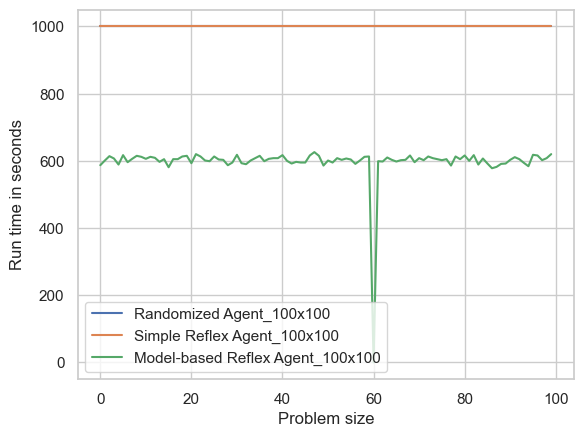

In [27]:
import matplotlib.pyplot as plt

# add a grid to the plots
import seaborn as sns 
sns.set(style="whitegrid")
x = range(N)
plt.plot(x, df1["Randomized Agent_100x100"], label = "Randomized Agent_100x100") 
plt.plot(x, df1["Simple Reflex Agent_100x100"], label = "Simple Reflex Agent_100x100") 
plt.plot(x, df1["Model-based Reflex Agent_100x100"], label = "Model-based Reflex Agent_100x100") 
plt.xlabel("Problem size")
plt.ylabel("Run time in seconds")
plt.legend()
plt.show()

In [34]:
import numpy as np  
import pandas as pd
n_max = 100
runtime1 = {
    "Randomized Agent_5x5" :  (num_cleanedR55),
    "Simple Reflex Agent_5x5" :  (num_cleanedS55),
    "Model-based Reflex Agent_5x5" :  (num_cleanedM55),
    "Randomized Agent_10x10" :  (num_cleanedR1010),
    "Simple Reflex Agent_10x10" :  (num_cleanedS1010),
    "Model-based Reflex Agent_10x10" :  (num_cleanedM1010),
    "Randomized Agent_100x100" :(num_cleanedR100100),
    "Simple Reflex Agent_100x100" :  (num_cleanedS100100),
    "Model-based Reflex Agent_100x100" :  (num_cleanedM100100)

}
# show data as a data frame using pandas
df2 = pd.DataFrame(runtime1)
df2

,Randomized Agent_5x5,Simple Reflex Agent_5x5,Model-based Reflex Agent_5x5,Randomized Agent_10x10,Simple Reflex Agent_10x10,Model-based Reflex Agent_10x10,Randomized Agent_100x100,Simple Reflex Agent_100x100,Model-based Reflex Agent_100x100
0,2.0,8.0,10.0,5.0,11.0,13.0,20.0,33.0,87.0
1,6.0,8.0,10.0,4.0,7.0,6.0,23.0,63.0,98.0
2,4.0,7.0,10.0,2.0,12.0,5.0,26.0,71.0,109.0
3,1.0,10.0,10.0,5.0,12.0,15.0,16.0,49.0,105.0
4,6.0,10.0,10.0,1.0,6.0,5.0,17.0,33.0,86.0
...,...,...,...,...,...,...,...,...,...
95,5.0,7.0,10.0,2.0,15.0,10.0,21.0,61.0,115.0
96,5.0,7.0,10.0,1.0,11.0,16.0,24.0,62.0,110.0
97,5.0,9.0,10.0,3.0,10.0,13.0,27.0,64.0,98.0
98,5.0,9.0,10.0,5.0,19.0,10.0,24.0,29.0,107.0


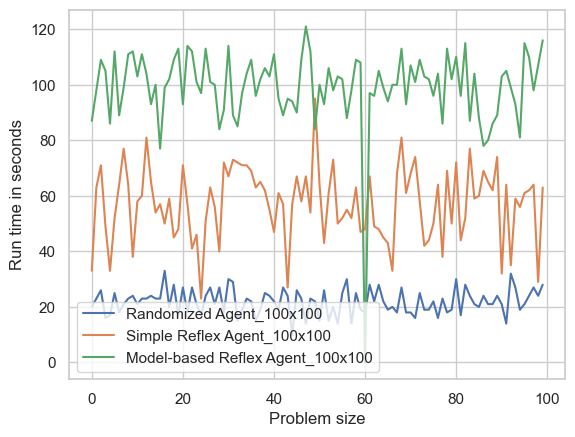

In [35]:
x = range(N)
plt.plot(x, df2["Randomized Agent_100x100"], label = "Randomized Agent_100x100") 
plt.plot(x, df2["Simple Reflex Agent_100x100"], label = "Simple Reflex Agent_100x100") 
plt.plot(x, df2["Model-based Reflex Agent_100x100"], label = "Model-based Reflex Agent_100x100") 
plt.xlabel("Problem size")
plt.ylabel("Run time in seconds")
plt.legend()
plt.show()

Mean performance: Randomized Agent_5x5                 4.28
Simple Reflex Agent_5x5              8.35
Model-based Reflex Agent_5x5        10.00
Randomized Agent_10x10               4.22
Simple Reflex Agent_10x10           11.08
Model-based Reflex Agent_10x10       9.53
Randomized Agent_100x100            21.91
Simple Reflex Agent_100x100         57.18
Model-based Reflex Agent_100x100    99.15
dtype: float64


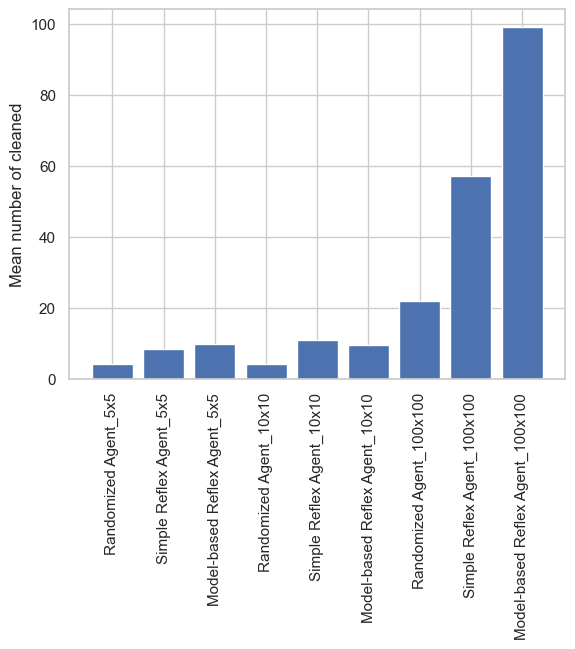

In [46]:
mean_performance = np.mean((df2), axis =0 )

print(f"Mean performance: {mean_performance}")

plt.bar(df2.keys(), mean_performance)
plt.ylabel("Mean number of cleaned")
plt.xticks(rotation=90)
plt.show()

I can see that the model-based Reflex agent overally can perform better in both cleaning and checking all the areas of the room as it has a memory and can learn the model effectively in addition to not bumping to the bumper . The simple reflex works better than randomized agent in cleaning as it can save energy not bumping the wall but it can be as inefficient as randomized agent in performance measure. I also can see that the number of cleaning areas not in Model-base and simple reflex will improve in bigger area but for randomized it is very random.

## Task 5: Robustness of the agent implementations [10 Points]

Describe how **your agent implementations** will perform

* if it is put into a rectangular room with unknown size,
* if the cleaning area can have an irregular shape (e.g., a hallway connecting two rooms), or
* if the room contains obstacles (i.e., squares that it cannot pass through and trigger the bumper sensors).
* if the dirt sensor is not perfect and gives 10% of the time a wrong reading (clean when it is dirty or dirty when it is clean).
* if the bumper sensor is not perfect and 10% of the time does not report a wall when there is one.

#### Unknown Size:
All of my agents design to clean the room indepent on the size of the room as I have define the size in the function. but I generally expect that Model-Based Reflex agent likely to perform better.If I want to compare the models in general

- Model-based Reflex:  the model-based reflex agent can adapt better because it creates a representation (model) of the environment and updates it as it moves. This allows it to improve over time as it learns the boundaries of the room. The agent would learn the room's dimensions as it explores, storing previously visited locations and adjusting its cleaning strategy accordingly. It may take longer initially, but the agent will improve as it maps the room.

- Simple Reflex Agent: The agent does not have memory, so it doesn't know whether it's reached the boundary of the room or revisited areas. It would continue operating based on local conditions (dirt or walls), which might lead to inefficient behavior, like revisiting areas multiple times.

- Randomized Agent:The randomized agent would randomly move around the room and may be able to clean all areas eventually, but its performance would be very inefficient due to the lack of knowledge about room boundaries or locations that have already been cleaned.

#### Irregular shape: 
In my models the randomized and simple reflex can use for this model but they are not efficient and potentially not cleaning all the areas or miss a room. my Model-based reflex is not able to do it as it needs the model to know the plan first. but if I want to compare the models in general

- Model-based Reflex:The model-based agent can adapt to irregular shapes as it explores and maps the environment. It would recognize the hallway and rooms as part of its model and adjust its cleaning path, ensuring that all areas are cleaned efficiently. The model-based reflex agent can adapt to irregular shapes better because it maintains a model, but it may take longer to cover all areas initially.

- Simple Reflex Agent: It would still follow simple rules based on the current situation, but might miss parts of the hallway or spend a lot of time in one room without recognizing the need to clean another area.

- Randomized Agent:In an irregular shape, the randomized agent might spend a lot of time in one area without effectively cleaning the whole environment. It would have difficulty efficiently covering the hallway and multiple rooms.

#### room contains obstacles: 
- Model-based Reflex Agent:The agent would detect obstacles and update its model without hitting them, avoiding those areas and focusing on reachable sections. Over time, it would create an efficient cleaning path around the obstacles.


- Simple Reflex Agent: This agent would rely on local perception. it doesn't know where obstacles are located unless they are directly in its perception at that moment.If it precept an obstacle, it will just change direction. It won't remember where obstacles are located.also due to its reliance on local perception, it may easily get stuck in loops or miss certain areas if obstacles aren't detected right away.

- Randomized Agent:The randomized agent would bump into obstacles frequently and randomly move in other directions. This lack of planning would make it highly inefficient in environments with obstacles.

#### dirt sensor is not perfect: 
all the agents will struggles because their decisions are based on the sensor's input. they will reclean some clean areas and not clean some dirty spaces, all of them will be inefficient

#### bumper sensor is not perfect : 
all the agents will struggle, they will bump the wall or bumper when there is a wall but not recognized by the sensor or it can recognize there is a wall in front of the agents but there is not and it will lead to not cleaning or checking that area.

## Advanced task: Imperfect Dirt Sensor

* __Graduate students__ need to complete this task [10 points]
* __Undergraduate students__ can attempt this as a bonus task [max +5 bonus points].

1. Change your simulation environment to run experiments for the following problem: The dirt sensor has a 10% chance of giving the wrong reading. Perform experiments to observe how this changes the performance of the three implementations. Your model-based reflex agent is likely not able to clean the whole room, so you need to measure performance differently as a tradeoff between energy cost and number of uncleaned squares.

2. Design an implement a solution for your model-based agent that will clean better. Show the improvement with experiments.

In [48]:
import numpy as np

# Example 5x5 matrix representing the environment
env_matrix = np.random.choice([0, 1], size=(5, 5), p=[0.8, 0.2])  # 0.8 chance of 0, 0.2 chance of 1

def apply_sensor_noise(env_matrix, error_rate=0.1):
    # Create a noise mask with a 10% chance of flipping the reading
    noise = np.random.choice([0, 1], size=env_matrix.shape, p=[1-error_rate, error_rate])
    
    # Flip the values based on the noise mask
    noisy_matrix = np.where(noise == 1, 1 - env_matrix, env_matrix)
    
    return noisy_matrix

# Apply the sensor noise with a 10% error rate
noisy_env_matrix = apply_sensor_noise(env_matrix, error_rate=0.1)

print("Original Matrix:")
print(env_matrix)

print("\nNoisy Matrix:")
print(noisy_env_matrix)


Original Matrix:
[[1 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 1]
 [1 0 1 0 1]]

Noisy Matrix:
[[1 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 1]
 [0 0 0 0 1]
 [1 0 1 0 1]]


### I think for measuring performance I should use F1 scores precision (correct cleanings / total cleanings) and recall (correct cleanings / total dirty spots). 
### For solution, I think we can have multiple sensors or multiple time reading to make sure the reading is accurate

## More advanced implementation tasks

* __Obstacles:__ Change your simulation environment to run experiments for the following problem: Add random obstacle squares that also trigger the bumper sensor. The agent does not know where the obstacles are. Perform experiments to observe how this changes the performance of the three implementations. Describe what would need to be done to perform better with obstacles. Add code if you can.

* __Agent for and environment with obstacles:__ Implement an agent for an environment where the agent does not know how large the environment is (we assume it is rectangular), where it starts or where the obstacles are. An option would be to always move to the closest unchecked/uncleaned square (note that this is actually depth-first search).

* __Utility-based agent:__ Change the environment for a $5 \times 5$ room, so each square has a fixed probability of getting dirty again. For the implementation, we give the environment a 2-dimensional array of probabilities. The utility of a state is defined as the number of currently clean squares in the room. Implement a utility-based agent that maximizes the expected utility over one full charge which lasts for 100000 time steps. To do this, the agent needs to learn the probabilities with which different squares get dirty again. This is very tricky!

In [29]:
# Your ideas/code